# Deep SARSA vs Advantage Actor-Critic on LunarLander-v3
**SEAI Project — Francesco Galardi, Andrea Vagnoli**

This notebook provides an interactive analysis of the training results,
including learning curves, statistical tests, inference time comparison,
and generalisation across environment variants.

## Setup
Run `pip install -r requirements.txt` before executing this notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml, json, torch

from src.utils.metrics import (
    compute_statistics, welch_t_test,
    plot_comparison, plot_inference_time, load_seed_rewards
)
from src.environment.lunar_lander_wrapper import ENV_VARIANTS

sns.set_theme(style='whitegrid', palette='colorblind')
print('Environment ready ✓')

Environment ready ✓


## 1. MDP Description — LunarLander-v3

| Property | Details |
|----------|---------|
| **State space** | ℝ⁸ (continuous): x, y, vx, vy, angle, angular velocity, left/right leg contact |
| **Action space** | Discrete(4): do nothing, fire left, fire main, fire right |
| **Reward** | Dense: shaped reward for position, velocity, angle; ±100 for landing/crash |
| **Episode termination** | Lander touches ground or goes out of bounds |
| **Stochasticity** | Initial position/velocity sampled randomly; optional wind/turbulence |

In [2]:
# Load configs
with open('../config/sarsa_config.yaml') as f:
    sarsa_cfg = yaml.safe_load(f)
with open('../config/actor_critic_config.yaml') as f:
    ac_cfg = yaml.safe_load(f)

print('SARSA hyperparameters:')
print(json.dumps(sarsa_cfg['agent'], indent=2))
print('\nA2C hyperparameters:')
print(json.dumps(ac_cfg['agent'], indent=2))

SARSA hyperparameters:
{
  "alpha": 0.0003,
  "gamma": 0.99,
  "epsilon_start": 1.0,
  "epsilon_end": 0.01,
  "epsilon_decay": 0.9975,
  "target_update_freq": 25,
  "batch_size": 64,
  "buffer_capacity": 50000
}

A2C hyperparameters:
{
  "actor_lr": 0.0003,
  "critic_lr": 0.001,
  "gamma": 0.99,
  "entropy_coef": 0.01,
  "n_steps": 5
}


## 2. Learning Curves

In [3]:
LOG_DIR = '../results/logs'
seeds_sarsa = sarsa_cfg['training']['seeds']
seeds_ac    = ac_cfg['training']['seeds']

sarsa_rewards = load_seed_rewards(LOG_DIR, 'sarsa', seeds_sarsa)
ac_rewards    = load_seed_rewards(LOG_DIR, 'ac',    seeds_ac)

print(f'SARSA seeds loaded: {len(sarsa_rewards)}')
print(f'A2C   seeds loaded: {len(ac_rewards)}')

SARSA seeds loaded: 5
A2C   seeds loaded: 5


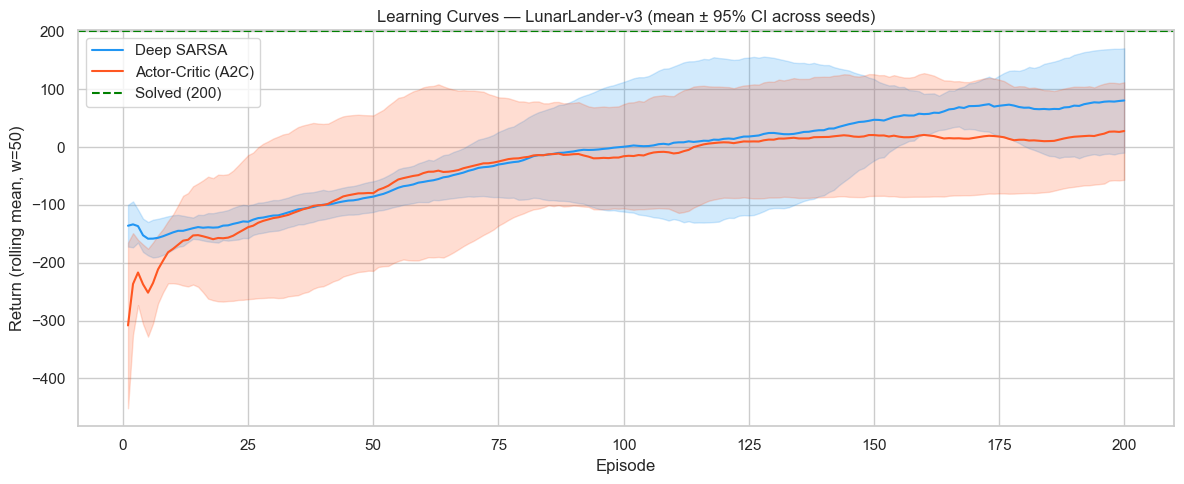

In [4]:
WINDOW = 50
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'sarsa': '#2196F3', 'ac': '#FF5722'}

for name, rewards, color in [
    ('Deep SARSA', sarsa_rewards, colors['sarsa']),
    ('Actor-Critic (A2C)', ac_rewards, colors['ac']),
]:
    if not rewards:
        continue
    ep, mean, _, ci95 = compute_statistics(rewards, WINDOW)
    ax.plot(ep, mean, label=name, color=color, linewidth=1.5)
    ax.fill_between(ep, mean - ci95, mean + ci95, alpha=0.2, color=color)

ax.axhline(200, color='green', linestyle='--', label='Solved (200)')
ax.set_xlabel('Episode')
ax.set_ylabel(f'Return (rolling mean, w={WINDOW})')
ax.set_title('Learning Curves — LunarLander-v3 (mean ± 95% CI across seeds)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/learning_curves.png', dpi=150)
plt.show()

## 3. Statistical Analysis

In [5]:
LAST_N = 100
finals_sarsa = [np.mean(r[-LAST_N:]) for r in sarsa_rewards]
finals_ac    = [np.mean(r[-LAST_N:]) for r in ac_rewards]

print(f'Deep SARSA — mean: {np.mean(finals_sarsa):.2f}, std: {np.std(finals_sarsa):.2f}')
print(f'A2C         — mean: {np.mean(finals_ac):.2f}, std: {np.std(finals_ac):.2f}')

result = welch_t_test(finals_sarsa, finals_ac)
print(f"\nWelch's t-test: {result['verdict']}")
print(f"  t = {result['t_statistic']}, p = {result['p_value']}")

Deep SARSA — mean: 63.87, std: 28.39
A2C         — mean: 24.24, std: 96.55

Welch's t-test: No significant difference (p=0.4689 ≥ 0.05)
  t = 0.7876, p = 0.468885


## 4. Generalisation Across Environment Variants

Agent      Actor-Critic (A2C)  Deep SARSA
Variant                                  
heavy             -612.222778 -434.599744
standard          -632.989887 -477.719901
turbulent         -613.216695 -427.012842
wind              -623.668147 -387.004501


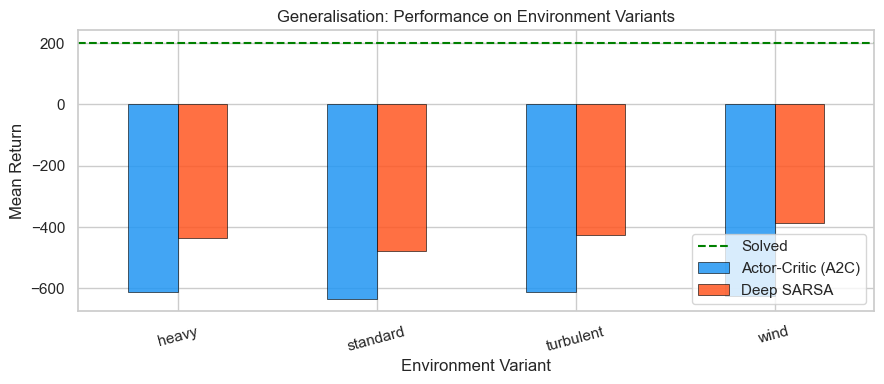

In [6]:
# Load evaluation results if available
import os
eval_path = '../results/evaluation_results.json'

if os.path.exists(eval_path):
    with open(eval_path) as f:
        eval_results = json.load(f)

    rows = []
    for agent_name, variants in eval_results.items():
        for variant, metrics in variants.items():
            rows.append({
                'Agent': 'Deep SARSA' if agent_name == 'sarsa' else 'Actor-Critic (A2C)',
                'Variant': variant,
                'Mean Return': metrics['mean_reward'],
                'Std': metrics['std_reward'],
            })

    df = pd.DataFrame(rows)
    pivot = df.pivot(index='Variant', columns='Agent', values='Mean Return')
    print(pivot.to_string())

    fig, ax = plt.subplots(figsize=(9, 4))
    pivot.plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'], alpha=0.85,
               edgecolor='black', linewidth=0.5)
    ax.axhline(200, color='green', linestyle='--', label='Solved')
    ax.set_xlabel('Environment Variant')
    ax.set_ylabel('Mean Return')
    ax.set_title('Generalisation: Performance on Environment Variants')
    ax.legend()
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('../results/generalisation.png', dpi=150)
    plt.show()
else:
    print('Run evaluate.py first to generate evaluation_results.json')

## 5. Inference Time Analysis

In [7]:
# Measure inference time on CPU
import time
import gymnasium as gym
from src.networks.sarsa_network import SARSANetwork
from src.networks.actor_critic_network import ActorNetwork

state_dim, action_dim = 8, 4
dummy_state = torch.randn(1, state_dim)

sarsa_net = SARSANetwork(state_dim, action_dim)
actor_net = ActorNetwork(state_dim, action_dim)

N = 1000
sarsa_times, ac_times = [], []

with torch.no_grad():
    for _ in range(N):
        t = time.perf_counter()
        sarsa_net(dummy_state).argmax(dim=1)
        sarsa_times.append(time.perf_counter() - t)

        t = time.perf_counter()
        actor_net(dummy_state).sample()
        ac_times.append(time.perf_counter() - t)

print(f'Deep SARSA  inference: {np.mean(sarsa_times)*1e3:.4f} ms ± {np.std(sarsa_times)*1e3:.4f}')
print(f'Actor-Critic inference: {np.mean(ac_times)*1e3:.4f} ms ± {np.std(ac_times)*1e3:.4f}')

plot_inference_time(sarsa_times, ac_times, save_path='../results/inference_time.png')

Deep SARSA  inference: 0.0204 ms ± 0.0128
Actor-Critic inference: 0.0543 ms ± 0.0201
[metrics] Inference-time plot saved → ../results/inference_time.png


## 6. Failure Analysis

Fill in after running the experiments. Key questions to address:
- In which scenarios does each agent fail most often?
- Does SARSA exhibit more variance due to the on-policy constraint?
- Does A2C suffer from catastrophic forgetting in wind/turbulent variants?
- What is the effect of the entropy coefficient on exploration?